In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/deepfake-face-images/Final Dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/deepfake-face-images/Final Dataset/dataset.csv
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_639_aug_1.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/1JD6S89G4D.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/1KCN62R2WA.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/1FKIB1PX33.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/0AMO1SB5CD.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_46_aug_3.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_373_aug_3.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_510_aug_2.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/0ICRTX548O.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_61_aug_2.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_649_aug_2.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_436_aug_2.jpg
/kaggle/input/deepfake-face-images/Final Dataset/Fake/fake_211_aug_0.jpg
/kaggle/inpu

In [2]:
import tensorflow as tf
import pathlib
import numpy as np

# --- 1. DEFINE YOUR CONSTANTS (Must be IDENTICAL to your training script) ---

# --- ⬇️ 1. UPDATE THIS PATH ⬇️ ---
# This is the single folder that contains your 'real' and 'fake' subfolders
DATA_DIR = pathlib.Path('/kaggle/input/deepfake-face-images/Final Dataset')
# --- ⬆️ 1. UPDATE THIS PATH ⬆️ ---

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 123 # <--- This MUST be the same seed you used for training

# --- 2. RE-CREATE THE TRAINING DATASET (Needed to get CLASS_NAMES) ---
print("Loading 'train_dataset' (to get class names)...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# --- 3. RE-CREATE THE VALIDATION DATASET ---
print("Loading 'validation_dataset'...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# --- 4. RE-CREATE THE CLASS_NAMES VARIABLE ---
CLASS_NAMES = train_dataset.class_names
print(f"Classes found and recreated: {CLASS_NAMES}")

# --- 5. CONFIGURE DATASET FOR PERFORMANCE (Good practice for .predict) ---
AUTOTUNE = tf.data.AUTOTUNE
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("\n--- ✅ Success! ---")
print("The 'validation_dataset' and 'CLASS_NAMES' variables are now back in memory.")
print("You can now run the visualization code cell.")

2025-11-04 21:21:50.209735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762291310.415130      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762291310.479331      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Loading 'train_dataset' (to get class names)...
Found 12890 files belonging to 2 classes.
Using 10312 files for training.
Loading 'validation_dataset'...


2025-11-04 21:22:05.663770: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 12890 files belonging to 2 classes.
Using 2578 files for validation.
Classes found and recreated: ['Fake', 'Real']

--- ✅ Success! ---
The 'validation_dataset' and 'CLASS_NAMES' variables are now back in memory.
You can now run the visualization code cell.


Loading saved model from: /kaggle/input/ee604-resnet50/my_deepfake_detector.keras
Model loaded successfully.
Making predictions on the validation set to verify...
81/81 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step

--- Verification: Classification Report ---
              precision    recall  f1-score   support

        Fake       0.97      0.91      0.94      1383
        Real       0.90      0.97      0.93      1195

    accuracy                           0.94      2578
   macro avg       0.94      0.94      0.94      2578
weighted avg       0.94      0.94      0.94      2578


--- Verification: Confusion Matrix ---


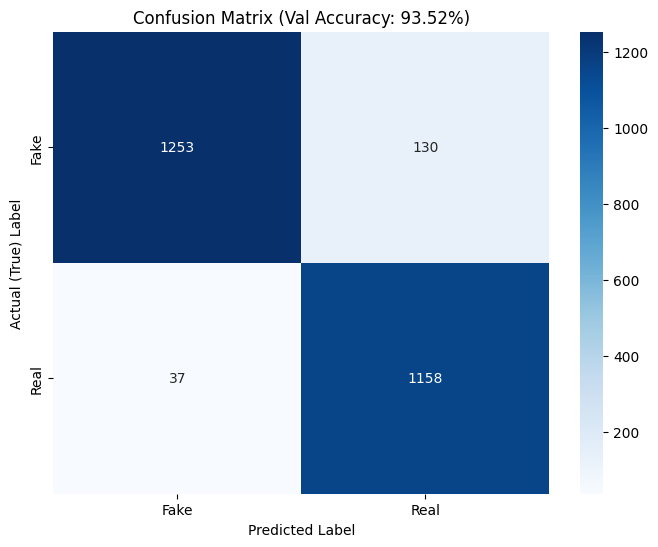


--- Verification: Visualizing Sample Predictions ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


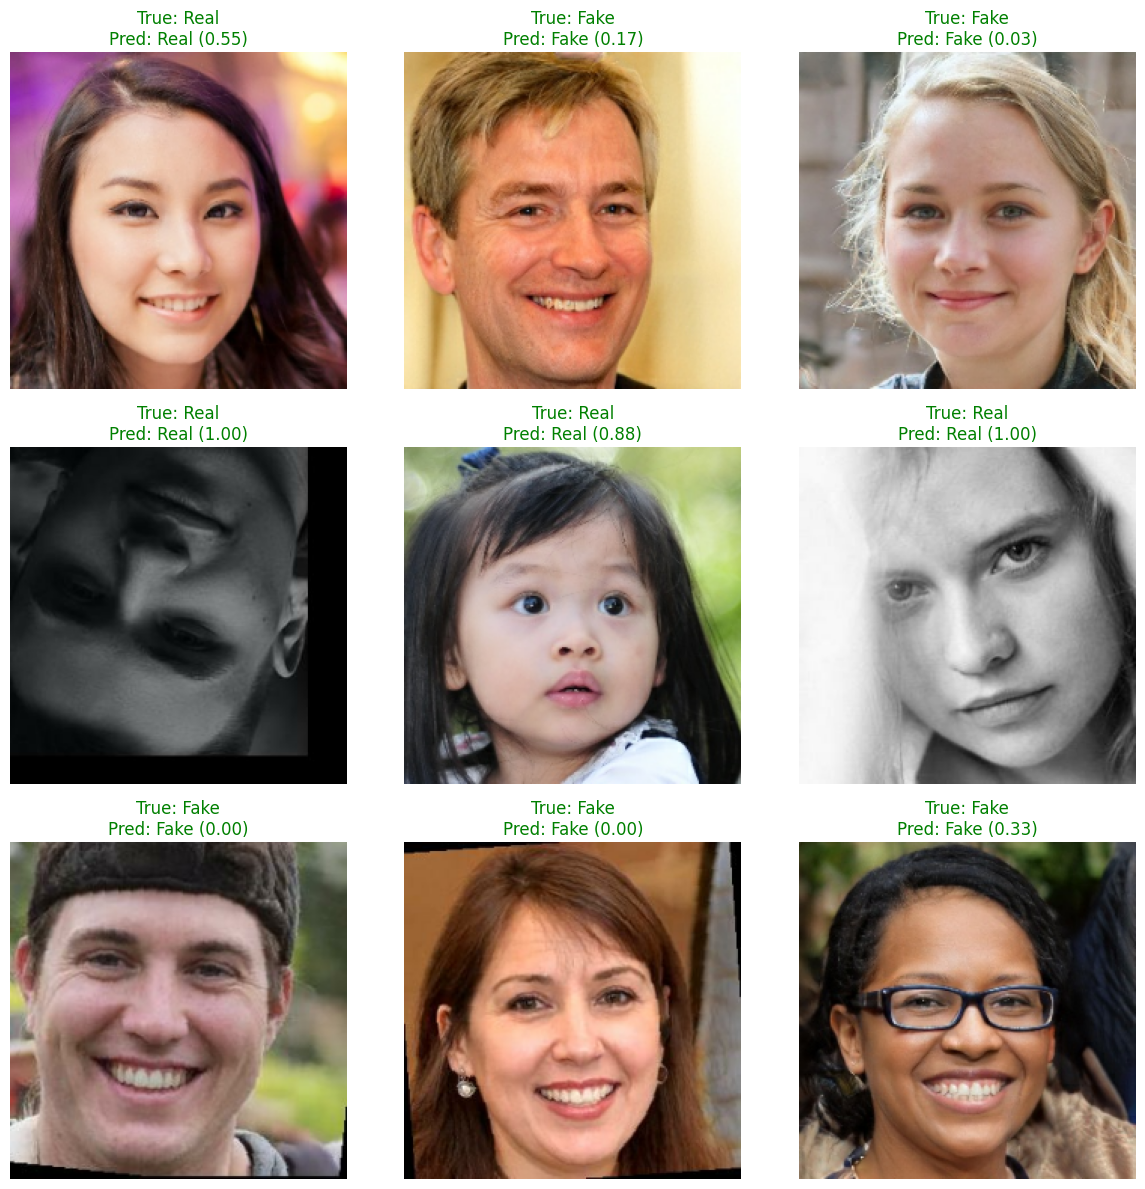

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# --- 1. DEFINE THE PATH TO YOUR SAVED MODEL ---
# ⬇️ UPDATE THIS PATH ⬇️
# Find the exact path from the "Input" panel on the right
MODEL_PATH = '/kaggle/input/ee604-resnet50/my_deepfake_detector.keras'
# ⬆️ UPDATE THIS PATH ⬆️

# --- 2. LOAD THE SAVED MODEL ---
print(f"Loading saved model from: {MODEL_PATH}")
# This loads your fully trained model from the 6-hour run
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully.")

# --- 3. GET ALL PREDICTIONS AND TRUE LABELS ---
print("Making predictions on the validation set to verify...")

# Get all the true labels from the validation_dataset (which you re-ran)
y_true = []
for images, labels in validation_dataset:
    y_true.extend(labels.numpy().astype(int))
y_true = np.array(y_true)

# Get all the model's predictions
y_pred_raw = model.predict(validation_dataset)
y_pred = (y_pred_raw > 0.5).astype(int)

# --- 4. PRINT CLASSIFICATION REPORT ---
print("\n--- Verification: Classification Report ---")
# CLASS_NAMES should be defined from when you re-ran the data-loading cell
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# --- 5. PLOT CONFUSION MATRIX ---
print("\n--- Verification: Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
val_accuracy = np.trace(cm) / np.sum(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix (Val Accuracy: {val_accuracy:.2%})')
plt.ylabel('Actual (True) Label')
plt.xlabel('Predicted Label')
plt.show()

# --- 6. PLOT VISUAL PREDICTIONS ---
print("\n--- Verification: Visualizing Sample Predictions ---")

plt.figure(figsize=(12, 12))
# Get one batch of images from the validation set
for images, labels in validation_dataset.take(1):
    # Make predictions on this batch
    batch_predictions = model.predict(images)
    
    for i in range(9): # Plot the first 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        true_label = CLASS_NAMES[int(labels[i])]
        pred_prob = batch_predictions[i][0]
        pred_label = CLASS_NAMES[1] if pred_prob > 0.5 else CLASS_NAMES[0]
        
        color = "green" if true_label == pred_label else "red"
        
        plt.title(f"True: {true_label}\nPred: {pred_label} ({pred_prob:.2f})", color=color)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import tensorflow as tf
import pathlib
import numpy as np

# --- 1. SET YOUR DATA DIRECTORY (THE 10K IMAGE FOLDER) ---
# --- ⬇️ 1. UPDATE THIS PATH ⬇️ ---
# This is the single folder that contains your 'real' and 'fake' subfolders
# DATA_DIR = pathlib.Path('path/to/your/10k_image_folder')
# --- ⬆️ 1. UPDATE THIS PATH ⬆️ ---

# --- 2. Create a NEW dataset with NO LABELS ---
print(f"Creating a new, label-less dataset from: {DATA_DIR}")
unlabeled_test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    label_mode=None,       # <--- The Proof: It loads ONLY images.
    image_size=(224, 224), # Must match your model's input
    batch_size=32,
    shuffle=False
)

# --- 3. Run predict on the dataset that has NO LABELS ---
try:
    print("\nAttempting model.predict() on the label-less dataset...")
    # 'model' must be loaded in memory from a previous cell
    predictions = model.predict(unlabeled_test_dataset)
    
    print("\n--- ✅ SUCCESS! ---")
    print(f"model.predict() ran perfectly on a dataset that 100% has no labels.")
    print("This proves the model only uses the images for prediction.")
    print(f"Shape of predictions: {predictions.shape} (batches, 1)")

except Exception as e:
    print(f"\n--- ❌ FAILED! ---")
    print(f"An error occurred: {e}")

Creating a new, label-less dataset from: /kaggle/input/deepfake-face-images/Final Dataset
Found 12890 files.

Attempting model.predict() on the label-less dataset...
403/403 ━━━━━━━━━━━━━━━━━━━━ 755s 2s/step

--- ✅ SUCCESS! ---
model.predict() ran perfectly on a dataset that 100% has no labels.
This proves the model only uses the images for prediction.
Shape of predictions: (12890, 1) (batches, 1)
